<a href="https://colab.research.google.com/github/ndpalomeque21/PROYECTO-BIG-DATA/blob/main/Taller_de_Clase_Regresi%C3%B3n_con_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrantes:
- William Sebastian Augurto Cedeño.
- Nadia Marcela Palomeque Pérez.
- Jesus Anthony Tinoco León.

ANÁLISIS EXPLORATORIO DE DATOS (EDA)

PASO 1 - Importar librerías

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

PASO 2 - Leer el dataset

In [33]:
df = pd.read_excel("Real estate valuation data set.xlsx")

df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


PASO 3 - Visualizar

In [34]:
df.shape

(414, 8)

PASO 4 - Información General

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


PASO 5 - Estadística descriptiva

In [36]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


PASO 6 - Buscar valores nulos

In [37]:
df.isnull().sum()

,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


PASO 7 - Buscar registros duplicados

In [38]:
df.duplicated().sum()

np.int64(0)

PASO 8 - Distribución de la variable objetivo

In [39]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

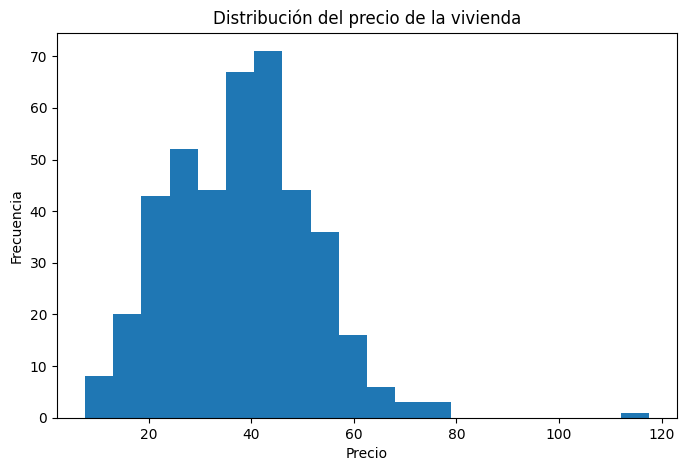

In [40]:
plt.figure(figsize=(8,5))

plt.hist(df["Y house price of unit area"], bins=20)

plt.title("Distribución del precio de la vivienda")

plt.xlabel("Precio")

plt.ylabel("Frecuencia")

plt.show()

PASO 9 - Matriz de correlación

In [42]:
import seaborn as sns

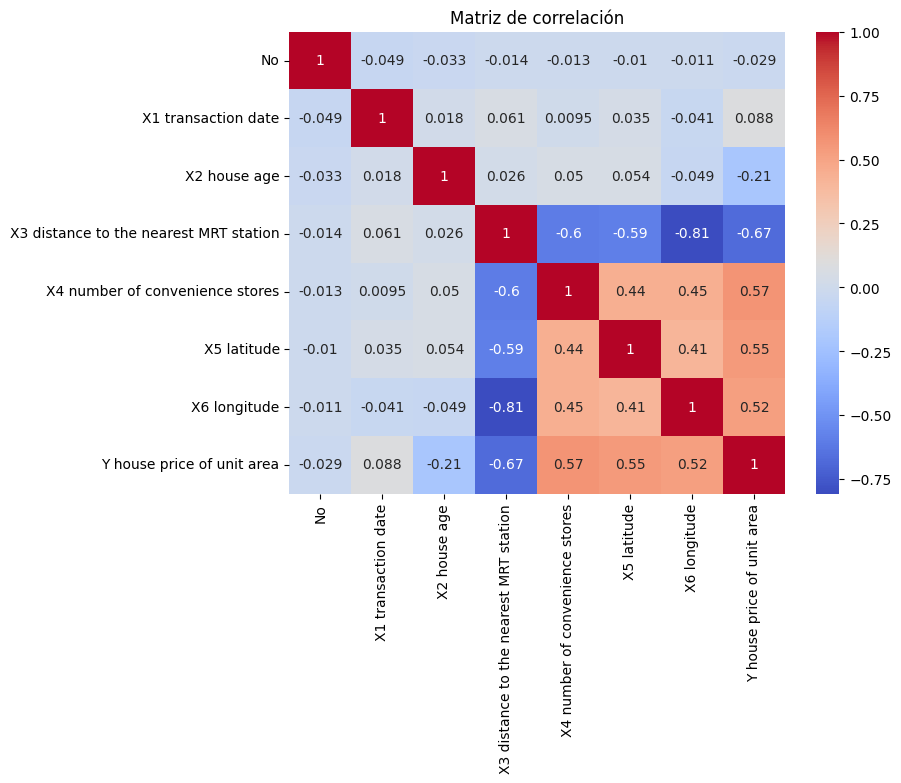

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

In [ ]:
PASO 10 - Boxplots

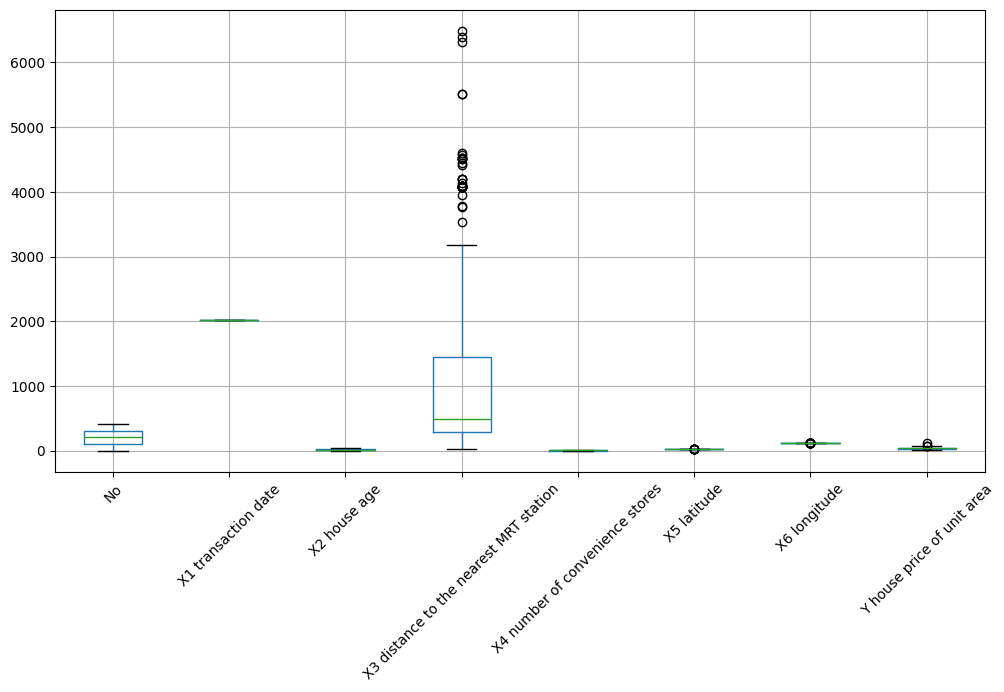

In [44]:
plt.figure(figsize=(12,6))

df.boxplot()

plt.xticks(rotation=45)

plt.show()

PROCESAMIENTO

PASO 11 - Eliminar la columna No

In [45]:
df = df.drop("No", axis=1)

PASO 12 - Separar X e Y

In [46]:
X = df.drop("Y house price of unit area", axis=1)

y = df["Y house price of unit area"]

PASO 13 - Dividir entrenamiento y prueba

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

PASO 14 - Escalar los datos

In [48]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)